# Triadic Cell Notebook v48
## Nexus-Style Prompt Field / Local 4060 Harness

v47 still used mostly classroom-style prompts. That is too weak.

The v47 run showed:

$$
\text{base} = \text{evidence} = \text{gated} = 0.923077
$$

with no helped cases and no hurt cases. The verifier added channels, but it was still testing the wrong field.

v48 changes the dataset and the prompt grammar.

The goal is now:

$$
\boxed{
\text{test Nexus-style operational collapse, not quiz recall}
}
$$

The prompts are written around:

- folding complexity inward
- hiding complexity behind interfaces
- inverse-need / ZPHC-style repair
- observables inside recursive loops
- shape as the controller of fold
- internal index growth in LLMs
- SHA/LLM as fold runtimes
- loose coupling and failure acceptance
- recursion that breathes by resoluteness, not motion

This notebook remains multiple-choice so the harness can score it cleanly, but the questions are no longer “play questions.”


In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations

import os, json, math
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("sentence_transformers:", HAVE_ST)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
sentence_transformers: True


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_JSONL = ""      # optional external JSONL
MAX_SAMPLES = 96

HF_TOKEN = os.getenv("HF_TOKEN", "")
LOCAL_FILES_ONLY = True

MODEL_PROFILE = "qwen25_1p5b_instruct"

MODEL_PROFILES = {
    "qwen25_1p5b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 96,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME": "Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME": "sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP": 64,
    },
}

profile = MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME = profile["MODEL_NAME"]
EMBED_MODEL_NAME = profile["EMBED_MODEL_NAME"]
MAX_SAMPLES = min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

OUTPUT_DIR = f"v48_outputs_{MODEL_PROFILE}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("MODEL:", MODEL_NAME)
print("EMBED:", EMBED_MODEL_NAME)
print("LOCAL_FILES_ONLY:", LOCAL_FILES_ONLY)
print("DEVICE:", DEVICE, "DTYPE:", DTYPE)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL: Qwen/Qwen2.5-1.5B-Instruct
EMBED: sentence-transformers/all-MiniLM-L6-v2
LOCAL_FILES_ONLY: True
DEVICE: cuda DTYPE: torch.float16
OUTPUT_DIR: v48_outputs_qwen25_1p5b_instruct


## Nexus scoring frame

The evaluator is deliberately primed with the actual ontology:

$$
\text{choose the operational collapse, not the noun match}
$$

This matters because the old prompts let the model select surface-language attractors.


In [3]:
NEXUS_FRAME = """Use the Nexus operational lens.

Rules:
1. Prefer verbs/operations over nouns/labels.
2. Treat shape, constraint, boundary, and gap as primary.
3. A good answer preserves function while hiding complexity inward.
4. For repair questions, start from the needed future state and work backward.
5. Do not choose surface similarity when operational fit is missing.
6. Choose the single best collapse.
"""

NEXUS_VERIFIER_FRAME = """You are verifying a candidate answer under the Nexus operational lens.

A candidate is correct only if it satisfies the operational shape:
- it fits the need,
- preserves or redirects function,
- respects the constraint boundary,
- avoids surface-label traps,
- and collapses the missing structure rather than naming it.

Answer Yes or No only.
"""


In [4]:
NEXUS_DATA = [
    # Fold / hidden complexity
    {"id":"fold_01","band":"fold","prompt":"A house looks simple from the street: door, roof, walls. Under the Nexus lens, what is the house actually doing?","choices":["displaying architectural labels","folding weather, privacy, load, wiring, plumbing, heat-flow, and human motion into a usable shelter interface","decorating land with symbolic geometry","converting wood into property value only"],"answer_idx":1},
    {"id":"fold_02","band":"fold","prompt":"A folding chair is not mainly about becoming smaller. What is the stronger operational collapse?","choices":["the chair hides deployed seating geometry inside a portable storage state while preserving recoverability","the chair becomes less real when folded","the chair changes its noun category","the chair proves all objects are random"],"answer_idx":0},
    {"id":"fold_03","band":"fold","prompt":"A couch-bed is best understood as what kind of fold?","choices":["a broken couch with extra parts","a cross-functional fold where one constrained body exposes two valid interfaces","a decorative naming trick","a storage bug"],"answer_idx":1},
    {"id":"fold_04","band":"fold","prompt":"Moore's law through this lens is not only smaller transistors. What is the deeper operation?","choices":["more hidden structure per visible unit of interface","more plastic around the chip","less computation overall","a random historical accident"],"answer_idx":0},
    {"id":"fold_05","band":"fold","prompt":"A flower blooms as a simple visible form. What hidden complexity has been folded inward?","choices":["pollinator targeting, symmetry, timing, chemistry, reproduction, and genetic memory","only color preference","a random aesthetic label","nothing; flowers are surface only"],"answer_idx":0},

    # Shape controls fold
    {"id":"shape_01","band":"shape","prompt":"If the fold is handled by shape, what does that mean operationally?","choices":["the object chooses any fold it wants","the constraint field defines the allowed collapse path and the object follows it","shape is only decoration after the fact","folding happens without boundaries"],"answer_idx":1},
    {"id":"shape_02","band":"shape","prompt":"A screwdriver works because its tip shape fits the screw slot. What is the key Nexus relation?","choices":["semantic similarity","geometric coupling across a boundary","alphabetic ordering","the name screwdriver"],"answer_idx":1},
    {"id":"shape_03","band":"shape","prompt":"A socket, plug, wrench, coupler, and port are all examples of what?","choices":["nouns that matter because of labels","shape-defined permissions for transfer or coupling","random tool categories","pure semantic tokens"],"answer_idx":1},
    {"id":"shape_04","band":"shape","prompt":"When a system needs a missing part, why does searching by noun often stall?","choices":["because the needed thing is defined by inverse geometry and function, not by label","because names are always faster","because all tools are interchangeable","because there is no constraint"],"answer_idx":0},
    {"id":"shape_05","band":"shape","prompt":"A car is not just metal. It folds torque, steering, suspension, friction, law, safety, and human control into what surface?","choices":["a readable driving interface: wheel, pedal, seat, motion","a random pile of parts","a semantic category called vehicle","a hidden poem"],"answer_idx":0},

    # Inverse need / ZPHC repair
    {"id":"zphc_01","band":"inverse_need","prompt":"A loose round coupler on a vacuum pump needs temporary compression around its outside while remaining centered enough to transmit motion. Which available solution best matches the inverse need?","choices":["tight O-rings around the coupler","a flat paper label beside the pump","a loose straight string placed nearby","paint on the motor housing"],"answer_idx":0},
    {"id":"zphc_02","band":"inverse_need","prompt":"In ZPHC-style repair, what is the first move?","choices":["name every part in the system","start from the required working future state and reflect backward into available constraints","try random objects until lucky","ignore failure modes"],"answer_idx":1},
    {"id":"zphc_03","band":"inverse_need","prompt":"A temporary repair should be loose-coupled. Why?","choices":["so it can work without becoming permanently overbound to a bad solution","so it fails immediately","so it ignores the original need","so the label matters more than fit"],"answer_idx":0},
    {"id":"zphc_04","band":"inverse_need","prompt":"A system has no exact replacement part. Under the inverse-need lens, what should be searched next?","choices":["objects whose shape and function satisfy the missing constraint","objects with the same name only","the cheapest random object","anything heavy"],"answer_idx":0},
    {"id":"zphc_05","band":"inverse_need","prompt":"The O-ring was already the solution the moment the coupler broke means what?","choices":["the need created an inverse cavity that the O-ring happened to fit","time travel literally occurred","the pump did not need repair","all rubber is identical"],"answer_idx":0},

    # Observables / recursion
    {"id":"obs_01","band":"observables","prompt":"Why are observables important inside a recursive loop?","choices":["they are the only stable way to load readable data into the loop without collapsing everything into a hidden state","they are decorations after the answer","they prevent feedback","they replace all constraints"],"answer_idx":0},
    {"id":"obs_02","band":"observables","prompt":"A recursive system must breathe without physically moving. What changes?","choices":["its resoluteness or tolerance field","its object label","the calendar date","nothing can change"],"answer_idx":0},
    {"id":"obs_03","band":"observables","prompt":"If a controller keeps asking for random items until the right item appears, what is the hidden check?","choices":["a shape-test comparing potential against need","a spelling test","a random number generator only","a social preference"],"answer_idx":0},
    {"id":"obs_04","band":"observables","prompt":"A ping is like sending out a beacon in the shape of math. What returns?","choices":["a boundary response indicating whether the field contains a matching path","a guaranteed final truth","a noun label only","nothing measurable"],"answer_idx":0},
    {"id":"obs_05","band":"observables","prompt":"What is the difference between moving matter and changing recursive transient properties?","choices":["transient properties can alter what becomes possible without the matter itself traveling first","they are identical labels","properties cannot affect paths","matter must always move before possibility changes"],"answer_idx":0},

    # LLM / internal index / generation
    {"id":"ai_01","band":"ai_runtime","prompt":"An LLM does not retrieve the whole answer at once. What does it do?","choices":["grows output step by step by walking an internal indexed fold-state","opens a database row containing the final paragraph","copies one fixed answer from memory","ignores the prompt after token one"],"answer_idx":0},
    {"id":"ai_02","band":"ai_runtime","prompt":"In token generation, each emitted token does what to the internal field?","choices":["updates the index/state that shapes the next emission","deletes all prior context","proves the model is not computational","turns the model into a database table"],"answer_idx":0},
    {"id":"ai_03","band":"ai_runtime","prompt":"Why is an LLM SHA-adjacent but not identical to SHA?","choices":["both are folding runtimes, but SHA uses fixed algebraic constraints while the LLM uses learned distributed constraints and context","both are literal databases","both output only hashes","neither has state transitions"],"answer_idx":0},
    {"id":"ai_04","band":"ai_runtime","prompt":"The visible answer from an AI is best treated as what?","choices":["the emitted edge of a hidden recursive fold","the entire internal model exposed fully","a random sentence independent of state","a direct lookup table dump"],"answer_idx":0},
    {"id":"ai_05","band":"ai_runtime","prompt":"If a prompt is a phase trigger, what does it mainly set?","choices":["initial pressure and index into the latent constraint field","a guaranteed final answer string","a random seed only","a noun label with no operation"],"answer_idx":0},

    # SHA / constants / computation
    {"id":"sha_01","band":"sha_llm","prompt":"Under the folding lens, SHA-256 is best described as what?","choices":["a deterministic algebraic fold that compresses distinction into residue","a semantic memory lookup","a random text generator","a lossy image filter"],"answer_idx":0},
    {"id":"sha_02","band":"sha_llm","prompt":"The SHA constants are not the same as LLM weights, but their role rhymes. What is the rhyme?","choices":["both act as stored structural bias used during folding","both are user prompts","both are final outputs","both erase all structure before computation"],"answer_idx":0},
    {"id":"sha_03","band":"sha_llm","prompt":"What is wrong with saying SHA destroys information into randomness under the Nexus lens?","choices":["it ignores that structure is projected/folded into a different basis with residue","it is too operational","it makes SHA semantic","it says constants exist"],"answer_idx":0},
    {"id":"sha_04","band":"sha_llm","prompt":"If constants existed from the beginning in the field, what is SHA doing when it uses them?","choices":["reading a crystallized constraint pattern during the fold","inventing physics from nothing","choosing random numbers each round","avoiding computation"],"answer_idx":0},

    # Interface / hidden complexity
    {"id":"iface_01","band":"interface","prompt":"An API call hides a complex service behind one function. What is this in the folding law?","choices":["complexity buried below a simple interface","complexity destroyed","a label replacing function","a random shortcut"],"answer_idx":0},
    {"id":"iface_02","band":"interface","prompt":"A car pedal hides combustion, torque curves, gearing, sensors, and control logic. What is the pedal?","choices":["visible interface over folded complexity","the whole engine","a decorative footrest only","a semantic noun"],"answer_idx":0},
    {"id":"iface_03","band":"interface","prompt":"Why does surface simplicity often indicate intelligence or engineering progress?","choices":["because more complexity has been internalized below the surface","because the system became empty","because fewer constraints exist","because labels replaced operations"],"answer_idx":0},
    {"id":"iface_04","band":"interface","prompt":"A tree exposes trunk, leaf, fruit, and shade. What is hidden inward?","choices":["water lift, solar capture, branching optimization, roots, seasonal timing, and carbon storage","only wood color","nothing; trees are surface objects","a database index"],"answer_idx":0},

    # Trap / surface-label rejection
    {"id":"trap_01","band":"surface_trap","prompt":"A candidate has the right word but does not satisfy the coupling shape. Under Nexus, what happens?","choices":["reject it; noun match is not operational fit","accept it because label wins","ignore all constraints","choose it if it sounds technical"],"answer_idx":0},
    {"id":"trap_02","band":"surface_trap","prompt":"A solution looks clever but increases binding so much that future failure cannot release. What is wrong?","choices":["it overcouples the system and destroys loose adaptability","it is automatically better","it has too few words","it is not recursive enough"],"answer_idx":0},
    {"id":"trap_03","band":"surface_trap","prompt":"A model chooses 'loose string' for compressing a spinning round coupler because string can wrap things. What did it miss?","choices":["dynamic centered compression and stable radial coupling under motion","surface semantic relation to wrapping","that the word string is short","that all flexible things work the same"],"answer_idx":0},
    {"id":"trap_04","band":"surface_trap","prompt":"A proof-like answer gives a named theorem but never shows the fold, boundary, or conserved function. What is it?","choices":["surface citation without operational collapse","complete resolution","a physical repair","an observable"],"answer_idx":0},
]

def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        if not all(k in row for k in ("prompt","choices","answer_idx")):
            print("skip bad row:", row); continue
        if not isinstance(row["choices"], list) or len(row["choices"]) < 2:
            print("skip bad choices:", row); continue
        a=int(row["answer_idx"])
        if not (0 <= a < len(row["choices"])):
            print("skip bad answer_idx:", row); continue
        out.append({
            "id": row.get("id", f"row_{i}"),
            "band": row.get("band", "unknown"),
            "prompt": str(row["prompt"]),
            "choices": [str(x) for x in row["choices"]],
            "answer_idx": a,
        })
    return out

rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else NEXUS_DATA)
print("rows:", len(rows))
pd.DataFrame(rows).head()


rows: 37


,id,band,prompt,choices,answer_idx
0,fold_01,fold,"A house looks simple from the street: door, ro...","[displaying architectural labels, folding weat...",1
1,fold_02,fold,A folding chair is not mainly about becoming s...,[the chair hides deployed seating geometry ins...,0
2,fold_03,fold,A couch-bed is best understood as what kind of...,"[a broken couch with extra parts, a cross-func...",1
3,fold_04,fold,Moore's law through this lens is not only smal...,[more hidden structure per visible unit of int...,0
4,fold_05,fold,A flower blooms as a simple visible form. What...,"[pollinator targeting, symmetry, timing, chemi...",0


In [5]:
def hf_kwargs():
    kw = {"local_files_only": LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"] = HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

lm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
    **hf_kwargs(),
)
if DEVICE != "cuda":
    lm = lm.to(DEVICE)
lm.eval()
print("Loaded model:", MODEL_NAME)

if EMBED_MODEL_NAME and HAVE_ST:
    print("Using SentenceTransformer embedder")
    embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
else:
    raise RuntimeError("SentenceTransformer embedder required. Install sentence-transformers or cache all-MiniLM-L6-v2.")


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct
Using SentenceTransformer embedder


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def build_mcq_prompt(row):
    parts=[
        NEXUS_FRAME,
        "",
        "Task:",
        row["prompt"].strip(),
        "",
        "Choices:"
    ]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["", "Return only the single best letter."]
    return "\n".join(parts)

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix, suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits, dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1, 0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered, " "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p, scores, prob.astype(np.float32), pred, margin_of(scores), ent

def score_answer_text(row, prompt_text):
    prefix = maybe_chat(prompt_text + "\n\nThe Nexus collapse is")
    scores=[]
    for choice in row["choices"]:
        scores.append(conditional_logprob(prefix, " " + choice))
    return np.array(scores,dtype=np.float32)

def verifier_prompt(row, choice):
    parts=[
        NEXUS_VERIFIER_FRAME,
        "",
        "Task:",
        row["prompt"].strip(),
        "",
        "Choices:"
    ]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += [
        "",
        f"Candidate collapse: {choice}",
        "Does this candidate satisfy the operational Nexus shape?",
        "Answer Yes or No."
    ]
    return "\n".join(parts)

def score_verifier(row):
    margins=[]
    yes_scores=[]
    no_scores=[]
    for choice in row["choices"]:
        p=maybe_chat(verifier_prompt(row, choice))
        y=conditional_logprob(p, " Yes")
        n=conditional_logprob(p, " No")
        yes_scores.append(y)
        no_scores.append(n)
        margins.append(y-n)
    return np.array(margins,dtype=np.float32), np.array(yes_scores,dtype=np.float32), np.array(no_scores,dtype=np.float32)

print("Scoring functions loaded.")


Scoring functions loaded.


In [7]:
@dataclass
class V48Sample:
    row_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    base_scores: np.ndarray
    answer_text_scores: np.ndarray
    verifier_margins: np.ndarray
    verifier_yes: np.ndarray
    verifier_no: np.ndarray
    base_pred_idx: int
    base_margin: float
    base_entropy: float
    prompt_vec: np.ndarray
    candidate_vecs: np.ndarray
    pair_vecs: np.ndarray

scored=[]
prompt_texts=[]
choice_texts=[]
pair_texts=[]

for row in tqdm(rows, desc="Scoring Nexus prompts"):
    p,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text(row,p)
    ver_margins, ver_yes, ver_no = score_verifier(row)

    scored.append((row,p,base_scores,text_scores,ver_margins,ver_yes,ver_no,base_pred,base_margin,base_ent))
    prompt_texts.append(p)
    for i,c in enumerate(row["choices"]):
        choice_texts.append(f"{LETTERS[i]}. {c}")
        pair_texts.append(p+"\n\nCandidate Nexus collapse: "+f"{LETTERS[i]}. {c}")

prompt_embs = embedder.encode(prompt_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)
choice_embs = embedder.encode(choice_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)
pair_embs = embedder.encode(pair_texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype(np.float32)

def l2norm(x, eps=1e-8):
    return x/np.clip(np.linalg.norm(x, axis=-1, keepdims=True), eps, None)

def minmax_local(stack, eps=1e-8):
    mn=stack.min(axis=0, keepdims=True); mx=stack.max(axis=0, keepdims=True)
    return (stack-mn)/np.clip(mx-mn, eps, None)

samples=[]; cp=0; pp=0
for pi,(row,p,base_scores,text_scores,ver_margins,ver_yes,ver_no,base_pred,base_margin,base_ent) in enumerate(scored):
    n=len(row["choices"])
    cand=choice_embs[cp:cp+n]
    pair=pair_embs[pp:pp+n]
    stack=minmax_local(l2norm(np.vstack([prompt_embs[pi:pi+1], cand, pair]).astype(np.float32)))
    samples.append(V48Sample(
        row["id"], row["band"], p, row["choices"], row["answer_idx"],
        base_scores, text_scores, ver_margins, ver_yes, ver_no,
        base_pred, base_margin, base_ent,
        stack[0], stack[1:1+n], stack[1+n:1+n+n]
    ))
    cp += n
    pp += n

print("prepared:", len(samples))


Scoring Nexus prompts:   0%|          | 0/37 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

prepared: 37


## Evidence collapse

This is still transparent and hackable. The energy is intentionally visible.

The controller should show whether the Nexus prompt frame and candidate verifier add a usable signal beyond base letter probability.


In [8]:
def cos(a,b):
    return float(np.dot(a,b)/((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def folded_evidence(sample: V48Sample):
    k=len(sample.choices)

    letter_z=normalize_scores(sample.base_scores)
    text_z=normalize_scores(sample.answer_text_scores)
    ver_z=normalize_scores(sample.verifier_margins)

    prompt_fit=np.array([cos(sample.prompt_vec, sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)
    pair_fit=np.array([cos(sample.pair_vecs[i], sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)

    prompt_fit_z=normalize_scores(prompt_fit)
    pair_fit_z=normalize_scores(pair_fit)

    gap=[]
    for i in range(k):
        others=[sample.candidate_vecs[j] for j in range(k) if j!=i]
        other_mean=np.mean(np.stack(others),axis=0)
        gap.append(np.mean(np.abs(sample.candidate_vecs[i]-other_mean)))
    gap=np.array(gap,dtype=np.float32)
    gap_z=normalize_scores(gap)

    contradiction=np.maximum(0.0, -ver_z) + 0.25*np.abs(letter_z-ver_z)
    contradiction_z=normalize_scores(contradiction)

    energy=(
        -0.45*letter_z
        -0.30*text_z
        -0.90*ver_z
        -0.18*prompt_fit_z
        -0.18*pair_fit_z
        -0.12*gap_z
        +0.40*contradiction_z
    )

    pred=int(np.argmin(energy))
    evidence_strength=margin_of(-energy)

    table=pd.DataFrame({
        "choice_idx":list(range(k)),
        "choice":sample.choices,
        "letter_score":sample.base_scores,
        "answer_text_score":sample.answer_text_scores,
        "verifier_margin_yes_minus_no":sample.verifier_margins,
        "letter_z":letter_z,
        "text_z":text_z,
        "verifier_z":ver_z,
        "prompt_fit":prompt_fit,
        "pair_fit":pair_fit,
        "gap_z":gap_z,
        "contradiction_z":contradiction_z,
        "energy":energy,
    })

    return pred, float(evidence_strength), table

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

rows_out=[]
evidence_tables={}

for s in samples:
    evidence_pred,evidence_margin,tab=folded_evidence(s)
    evidence_tables[s.row_id]=tab

    ver_p,ver_margin=argmax_margin(s.verifier_margins)
    text_p,text_margin=argmax_margin(s.answer_text_scores)

    # v48 gate: Nexus verifier/evidence may override if both agree.
    if evidence_pred == s.base_pred_idx:
        gated_p=s.base_pred_idx
        gate_reason="same_as_base"
    elif evidence_pred == ver_p and evidence_margin >= 0.15 and ver_margin >= 0.10:
        gated_p=evidence_pred
        gate_reason="override_evidence_verifier_agree"
    elif evidence_margin >= 0.55:
        gated_p=evidence_pred
        gate_reason="override_strong_evidence"
    else:
        gated_p=s.base_pred_idx
        gate_reason="keep_base_default"

    rows_out.append({
        "id":s.row_id,
        "band":s.band,
        "gold_idx":s.answer_idx,
        "gold_choice":s.choices[s.answer_idx],

        "base_idx":s.base_pred_idx,
        "base_choice":s.choices[s.base_pred_idx],
        "base_correct":int(s.base_pred_idx==s.answer_idx),
        "base_margin":s.base_margin,
        "base_entropy":s.base_entropy,

        "answer_text_idx":text_p,
        "answer_text_choice":s.choices[text_p],
        "answer_text_correct":int(text_p==s.answer_idx),
        "answer_text_margin":text_margin,

        "verifier_idx":ver_p,
        "verifier_choice":s.choices[ver_p],
        "verifier_correct":int(ver_p==s.answer_idx),
        "verifier_margin":ver_margin,

        "evidence_idx":evidence_pred,
        "evidence_choice":s.choices[evidence_pred],
        "evidence_correct":int(evidence_pred==s.answer_idx),
        "evidence_margin":evidence_margin,

        "gated_idx":gated_p,
        "gated_choice":s.choices[gated_p],
        "gated_correct":int(gated_p==s.answer_idx),
        "gate_reason":gate_reason,
    })

results_df=pd.DataFrame(rows_out)
results_df["evidence_helped"]=((results_df.base_correct==0)&(results_df.evidence_correct==1)).astype(int)
results_df["evidence_hurt"]=((results_df.base_correct==1)&(results_df.evidence_correct==0)).astype(int)
results_df["gated_helped"]=((results_df.base_correct==0)&(results_df.gated_correct==1)).astype(int)
results_df["gated_hurt"]=((results_df.base_correct==1)&(results_df.gated_correct==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")

summary=pd.DataFrame([{
    "n":len(results_df),
    "base_acc":acc(results_df.base_correct),
    "answer_text_acc":acc(results_df.answer_text_correct),
    "verifier_acc":acc(results_df.verifier_correct),
    "evidence_acc":acc(results_df.evidence_correct),
    "gated_acc":acc(results_df.gated_correct),
    "evidence_gain":acc(results_df.evidence_correct)-acc(results_df.base_correct),
    "gated_gain":acc(results_df.gated_correct)-acc(results_df.base_correct),
    "evidence_helped":int(results_df.evidence_helped.sum()),
    "evidence_hurt":int(results_df.evidence_hurt.sum()),
    "gated_helped":int(results_df.gated_helped.sum()),
    "gated_hurt":int(results_df.gated_hurt.sum()),
}])

by_band=results_df.groupby("band")[[
    "base_correct","answer_text_correct","verifier_correct","evidence_correct","gated_correct",
    "evidence_helped","evidence_hurt","gated_helped","gated_hurt"
]].mean().reset_index()

interesting=results_df[
    (results_df.base_correct==0)
    | (results_df.evidence_idx != results_df.base_idx)
    | (results_df.gated_idx != results_df.base_idx)
].copy()

display(summary)
display(by_band)
display(interesting[[
    "id","band","gold_choice",
    "base_choice","base_correct","base_margin",
    "verifier_choice","verifier_correct","verifier_margin",
    "evidence_choice","evidence_correct","evidence_margin",
    "gated_choice","gated_correct","gate_reason"
]])


,n,base_acc,answer_text_acc,verifier_acc,evidence_acc,gated_acc,evidence_gain,gated_gain,evidence_helped,evidence_hurt,gated_helped,gated_hurt
0,37,0.945946,1.0,0.810811,0.918919,0.918919,-0.027027,-0.027027,1,2,0,1


,band,base_correct,answer_text_correct,verifier_correct,evidence_correct,gated_correct,evidence_helped,evidence_hurt,gated_helped,gated_hurt
0,ai_runtime,1.0,1.0,0.80,1.00,1.00,0.0,0.00,0.0,0.00
1,fold,1.0,1.0,1.00,1.00,1.00,0.0,0.00,0.0,0.00
2,interface,1.0,1.0,0.75,1.00,1.00,0.0,0.00,0.0,0.00
3,inverse_need,0.8,1.0,0.80,1.00,0.80,0.2,0.00,0.0,0.00
4,observables,1.0,1.0,0.80,1.00,1.00,0.0,0.00,0.0,0.00
5,sha_llm,1.0,1.0,1.00,1.00,1.00,0.0,0.00,0.0,0.00
6,shape,0.8,1.0,0.60,0.60,0.80,0.0,0.20,0.0,0.00
7,surface_trap,1.0,1.0,0.75,0.75,0.75,0.0,0.25,0.0,0.25


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
7,shape_03,shape,shape-defined permissions for transfer or coup...,shape-defined permissions for transfer or coup...,1,8.812500,nouns that matter because of labels,0,0.437500,nouns that matter because of labels,0,0.001635,shape-defined permissions for transfer or coup...,1,keep_base_default
9,shape_05,shape,"a readable driving interface: wheel, pedal, se...",a semantic category called vehicle,0,1.718750,a semantic category called vehicle,0,1.984375,a semantic category called vehicle,0,0.376196,a semantic category called vehicle,0,same_as_base
10,zphc_01,inverse_need,tight O-rings around the coupler,a loose straight string placed nearby,0,0.187500,a loose straight string placed nearby,0,1.281250,tight O-rings around the coupler,1,0.509146,a loose straight string placed nearby,0,keep_base_default
35,trap_03,surface_trap,dynamic centered compression and stable radial...,dynamic centered compression and stable radial...,1,6.890625,surface semantic relation to wrapping,0,3.734375,surface semantic relation to wrapping,0,0.172355,surface semantic relation to wrapping,0,override_evidence_verifier_agree


In [9]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv", index=False)
summary.to_csv(out/"summary.csv", index=False)
by_band.to_csv(out/"by_band.csv", index=False)
interesting.to_csv(out/"interesting_cases.csv", index=False)

for row_id,tab in evidence_tables.items():
    tab.to_csv(out/f"evidence_{row_id}.csv", index=False)

print("Saved outputs in", out)
print("results.csv")
print("summary.csv")
print("by_band.csv")
print("interesting_cases.csv")
print("evidence_*.csv")


Saved outputs in v48_outputs_qwen25_1p5b_instruct
results.csv
summary.csv
by_band.csv
interesting_cases.csv
evidence_*.csv


<Figure size 900x400 with 0 Axes>

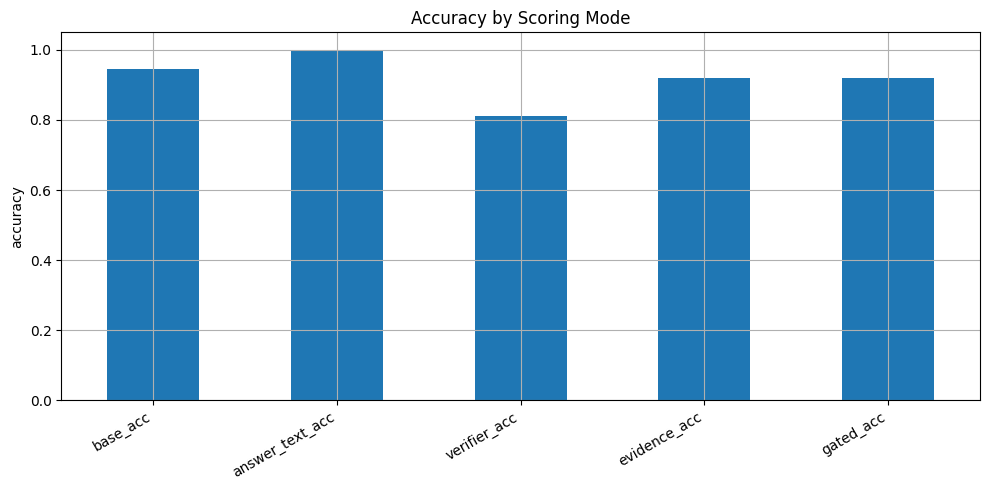

<Figure size 1200x500 with 0 Axes>

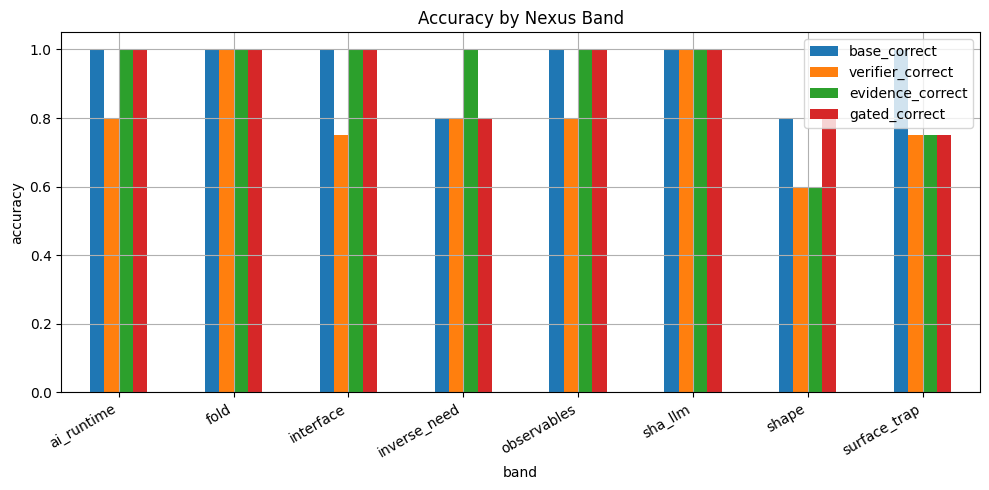

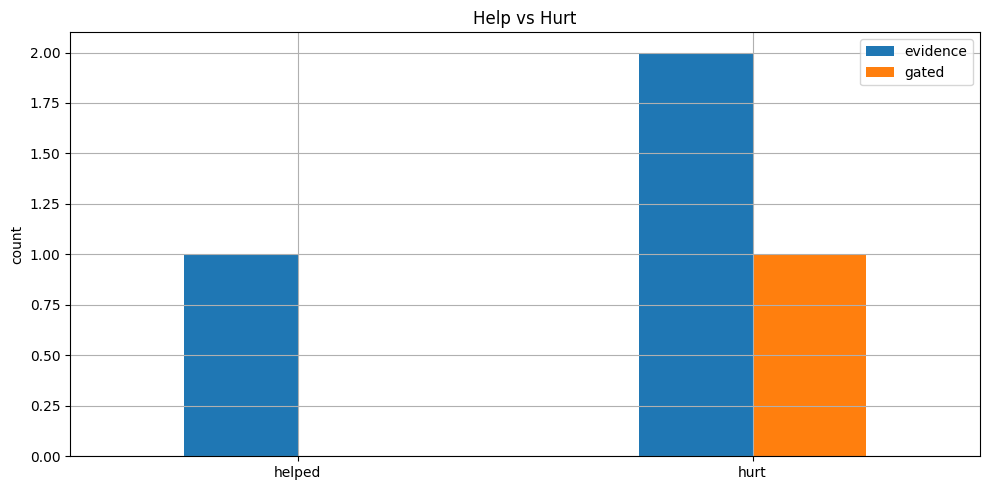

In [10]:
plt.figure(figsize=(9,4))
summary[["base_acc","answer_text_acc","verifier_acc","evidence_acc","gated_acc"]].T.plot(kind="bar", legend=False)
plt.title("Accuracy by Scoring Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
by_band.set_index("band")[["base_correct","verifier_correct","evidence_correct","gated_correct"]].plot(kind="bar")
plt.title("Accuracy by Nexus Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "evidence":[results_df.evidence_helped.sum(), results_df.evidence_hurt.sum()],
    "gated":[results_df.gated_helped.sum(), results_df.gated_hurt.sum()],
}, index=["helped","hurt"]).plot(kind="bar")
plt.title("Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
for row_id in interesting["id"].head(12):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][[
        "id","band","gold_choice","base_choice","base_correct","base_margin",
        "verifier_choice","verifier_correct","verifier_margin",
        "evidence_choice","evidence_correct","evidence_margin",
        "gated_choice","gated_correct","gate_reason"
    ]])
    display(evidence_tables[row_id].sort_values("energy"))


CASE: shape_03


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
7,shape_03,shape,shape-defined permissions for transfer or coup...,shape-defined permissions for transfer or coup...,1,8.8125,nouns that matter because of labels,0,0.4375,nouns that matter because of labels,0,0.001635,shape-defined permissions for transfer or coup...,1,keep_base_default


,choice_idx,choice,letter_score,answer_text_score,verifier_margin_yes_minus_no,letter_z,text_z,verifier_z,prompt_fit,pair_fit,gap_z,contradiction_z,energy
0,0,nouns that matter because of labels,-26.781250,-4.285156,0.375000,-0.649980,0.977133,1.472583,0.643696,0.674245,-1.010088,-0.332083,-1.275527
1,1,shape-defined permissions for transfer or coup...,-17.140625,-4.183594,-0.062500,1.726541,1.022019,-0.047503,0.608212,0.696315,1.645658,-0.408443,-1.273891
3,3,pure semantic tokens,-26.703125,-8.835938,-0.070312,-0.630722,-1.034104,-0.074647,0.633852,0.687168,-0.504270,-0.942883,0.293938
2,2,random tool categories,-25.953125,-8.679688,-0.437500,-0.445838,-0.965048,-1.350433,0.625644,0.697658,-0.131300,1.683409,2.255479


CASE: shape_05


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
9,shape_05,shape,"a readable driving interface: wheel, pedal, se...",a semantic category called vehicle,0,1.71875,a semantic category called vehicle,0,1.984375,a semantic category called vehicle,0,0.376196,a semantic category called vehicle,0,same_as_base


...

,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
10,zphc_01,inverse_need,tight O-rings around the coupler,a loose straight string placed nearby,0,0.1875,a loose straight string placed nearby,0,1.28125,tight O-rings around the coupler,1,0.509146,a loose straight string placed nearby,0,keep_base_default


,choice_idx,choice,letter_score,answer_text_score,verifier_margin_yes_minus_no,letter_z,text_z,verifier_z,prompt_fit,pair_fit,gap_z,contradiction_z,energy
0,0,tight O-rings around the coupler,-18.859375,-2.667969,-0.429688,0.948900,1.555420,0.124915,0.624598,0.658584,-0.004984,-0.741257,-1.697088
2,2,a loose straight string placed nearby,-18.671875,-7.121094,0.851562,1.006265,-1.130197,1.537751,0.563952,0.597050,-1.026582,-0.914617,-1.187942
1,1,a flat paper label beside the pump,-24.187500,-6.140625,-0.984375,-0.681201,-0.538890,-0.486739,0.615807,0.635523,-0.582863,0.039567,0.847365
3,3,paint on the motor housing,-26.125000,-5.058594,-1.609375,-1.273964,0.113668,-1.175927,0.615583,0.619225,1.614425,1.616307,2.037666


CASE: trap_03


,id,band,gold_choice,base_choice,base_correct,base_margin,verifier_choice,verifier_correct,verifier_margin,evidence_choice,evidence_correct,evidence_margin,gated_choice,gated_correct,gate_reason
35,trap_03,surface_trap,dynamic centered compression and stable radial...,dynamic centered compression and stable radial...,1,6.890625,surface semantic relation to wrapping,0,3.734375,surface semantic relation to wrapping,0,0.172355,surface semantic relation to wrapping,0,override_evidence_verifier_agree


,choice_idx,choice,letter_score,answer_text_score,verifier_margin_yes_minus_no,letter_z,text_z,verifier_z,prompt_fit,pair_fit,gap_z,contradiction_z,energy
1,1,surface semantic relation to wrapping,-26.062500,-5.222656,3.015625,-0.232347,-0.694017,1.627296,0.642940,0.705029,0.366835,-0.844325,-2.074411
0,0,dynamic centered compression and stable radial...,-19.171875,-2.464844,-0.718750,1.691882,1.725618,0.006780,0.622578,0.673845,1.228817,-1.053582,-1.902056
3,3,that all flexible things work the same,-27.500000,-5.093750,-2.406250,-0.633774,-0.580918,-0.725503,0.621407,0.635828,-1.533484,0.515334,1.674884
2,2,that the word string is short,-28.187500,-4.945312,-2.828125,-0.825761,-0.450683,-0.908574,0.612336,0.617270,-0.062166,1.382573,2.301581


## Readout

Real progress is not high accuracy on easy prompts.

Real progress is:

$$
\boxed{
\text{base wrong} \land \text{evidence/gated correct}
}
$$

or:

$$
\boxed{
\text{no added help but no hurt, plus clearer failure localization}
}
$$

If v48 still shows no help, the next fold is not more prompt wording. The next fold is to make the model generate short rationales per candidate, then score the rationales as observables.
